# Evaluate StarCE CompressPrecision

Testing the impact of different `CompressPrecision` values on StarCE accuracy, build time, and statistics size.

Covers 4 benchmarks: `STATS / JOBM / JOBLight / JOBLightRanges`, precision levels: `[1.1, 1.2, 1.5, 2.0]`.

Error metric: `relative_error = max(1, est) / max(1, true)`, plots use `log10(relative_error)`.

In [1]:
import os, sys, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import to_hex

sys.path.append(os.path.abspath('.'))
import plot_style

def get_project_root() -> Path:
    cwd = Path.cwd()
    for parent in [cwd] + list(cwd.parents):
        if (parent / "Benchmark").exists() and (parent / "experiment").exists():
            return parent
    if "experiment" in str(cwd):
        return cwd.parent
    return cwd

PROJECT_ROOT = get_project_root()
CHECKPOINT_ROOT = PROJECT_ROOT / "experiment" / "checkpoint" / "StarCE" / "compress_precision"
FIGURE_DIR = PROJECT_ROOT / "experiment" / "checkpoint" / "figures"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

PRECISION_LEVELS = [1.1, 1.2, 1.5, 2.0]
BENCHMARKS = ["STATS", "JOBM", "JOBLight", "JOBLightRanges"]

print(f"Project root: {PROJECT_ROOT}")
print(f"Checkpoint: {CHECKPOINT_ROOT}")
print(f"Figures: {FIGURE_DIR}")

Project root: /home/user/project/starce-final/StarCE
Checkpoint: /home/user/project/starce-final/StarCE/experiment/checkpoint/StarCE/compress_precision
Figures: /home/user/project/starce-final/StarCE/experiment/checkpoint/figures


---

# Experiment Section

Run StarCE, collect build time, statistics size, and subquery cardinality estimates, export to CSV.

In [2]:
# ============================================================
# Experiment Configuration
# ============================================================
from ExperimentRunner import StarCETestRunner, setup_starce_executable

RUN_STARCE = True       # Whether to run StarCE
NUM_RUNS = 3            # Number of build time measurements (warmup not counted)

print(f"RUN_STARCE={RUN_STARCE}, NUM_RUNS={NUM_RUNS}")

runner = StarCETestRunner(str(PROJECT_ROOT))
setup_starce_executable(PROJECT_ROOT, runner.running_space)

# Ensure dummy SQL exists
dummy_sql = runner.running_space / "dummy_query.sql"
if not dummy_sql.exists():
    dummy_sql.write_text("SELECT 1;\n")

RUN_STARCE=True, NUM_RUNS=3
Successfully copied starce executable to: /home/user/project/starce-final/StarCE/experiment/running_space/starce


In [3]:
# ============================================================
# Helper Functions
# ============================================================

def resolve_real_path(benchmark: str) -> Path:
    mapping = {
        "STATS": PROJECT_ROOT / "Benchmark/workloads/STATS-CEB/subquery/result/real.txt",
        "JOBM": PROJECT_ROOT / "Benchmark/workloads/JOBM/subquery/result/real.txt",
        "JOBLight": PROJECT_ROOT / "Benchmark/workloads/JOBLight/subquery/result/real.txt",
        "JOBLightRanges": PROJECT_ROOT / "Benchmark/workloads/JOBLightRanges/subquery/result/real.txt",
    }
    if benchmark not in mapping:
        raise ValueError(f"Unknown benchmark: {benchmark}")
    return mapping[benchmark]

def get_benchmark_config(benchmark: str):
    if benchmark == "STATS":      return runner.get_stats_config()
    if benchmark == "JOBM":       return runner.get_jobm_config()
    if benchmark == "JOBLight":   return runner.get_joblight_config()
    if benchmark == "JOBLightRanges": return runner.get_joblight_ranges_config()
    raise ValueError(f"Unknown benchmark: {benchmark}")

def precision_to_tag(p: float) -> str:
    return str(int(p)) if float(p).is_integer() else str(p)

def output_path(benchmark: str, p: float) -> Path:
    tag = precision_to_tag(p)
    out_dir = CHECKPOINT_ROOT / benchmark
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir / f"card_{benchmark}_cp{tag}.txt"

def read_txt_file(file_path: Path) -> list[float]:
    values = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            s = line.strip()
            if s:
                values.append(float(s))
    return values

def temp_stats_filename(benchmark: str, p: float) -> str:
    return f"statistics_{benchmark}_cp{precision_to_tag(p)}.json"

def measure_build_time(benchmark: str, compress_precision: float) -> dict:
    config = get_benchmark_config(benchmark)
    config.CompressPrecision = float(compress_precision)
    config.RefreshStatistics = 1
    config.RecordingSubquery = 0
    config.SQL_PATH = "dummy_query.sql"
    stats_file = temp_stats_filename(benchmark, compress_precision)
    config.STATS_PATH = stats_file
    stats_abs = runner.running_space / stats_file

    # warmup
    if stats_abs.exists():
        stats_abs.unlink()
    runner.save_config(config)
    runner.run_starce(suppress_output=True)

    times = []
    for run_i in range(NUM_RUNS):
        if stats_abs.exists():
            stats_abs.unlink()
        runner.save_config(config)
        success, elapsed = runner.run_starce(suppress_output=True)
        if success:
            times.append(elapsed)
        else:
            print(f"  WARNING: Run {run_i+1}/{NUM_RUNS} failed for {benchmark} c={compress_precision}")

    if not times:
        raise RuntimeError(f"All {NUM_RUNS} runs failed for {benchmark} c={compress_precision}")

    avg_time = sum(times) / len(times)
    size_path = runner.running_space / "statistics_size.json"
    with open(size_path, 'r') as f:
        size_report = json.load(f)
    size_bytes = size_report["data_only"]

    return {
        "benchmark": benchmark, "compress_precision": compress_precision,
        "build_time_sec": avg_time, "build_time_min": min(times), "build_time_max": max(times),
        "statistics_size_bytes": size_bytes, "statistics_size_mb": size_bytes / (1024 * 1024),
    }

def run_estimation(benchmark: str, compress_precision: float, out_path: Path) -> dict:
    config = get_benchmark_config(benchmark)
    config.CompressPrecision = float(compress_precision)
    config.RefreshStatistics = 0
    config.STATS_PATH = temp_stats_filename(benchmark, compress_precision)
    stats_abs = runner.running_space / config.STATS_PATH
    if not stats_abs.exists():
        raise FileNotFoundError(f"Stats not found: {stats_abs}. Run Phase 1 first.")

    queries_file = Path(config.SQL_PATH)
    explain_sql = runner.running_space / "explain.sql"
    runner._prepare_input_sql_with_explain(queries_file, explain_sql)
    config.RecordingSubquery = 1
    config.SUBQUERY_PATH = "null.sql"
    config.SQL_PATH = "explain.sql"
    config.SUBQUERY_RESULT_PATH = str(out_path)
    runner.save_config(config)

    start = time.time()
    success, _ = runner.run_starce(suppress_output=True)
    total = time.time() - start
    if not success:
        raise RuntimeError(f"StarCE failed: {benchmark}, CompressPrecision={compress_precision}")
    return {"benchmark": benchmark, "compress_precision": compress_precision,
            "output_file": str(out_path), "total_time_sec": total}

print("Helper functions defined.")

Helper functions defined.


In [4]:
# ============================================================
# Phase 1: Build Time + Statistics Size Measurement
# ============================================================
build_results = []
for benchmark in BENCHMARKS:
    for p in PRECISION_LEVELS:
        if RUN_STARCE:
            print(f"\n=== Phase 1 [{benchmark} c={p}]: Build time + size ===")
            r = measure_build_time(benchmark, p)
            build_results.append(r)
            print(f"  Build time: avg={r['build_time_sec']:.3f}s, min={r['build_time_min']:.3f}s, max={r['build_time_max']:.3f}s")
            print(f"  Stats size: {r['statistics_size_bytes']} bytes ({r['statistics_size_mb']:.2f} MB)")
        else:
            print(f"\n=== Phase 1 [{benchmark} c={p}]: SKIP ===")
            s = runner.running_space / temp_stats_filename(benchmark, p)
            sz = s.stat().st_size if s.exists() else None
            build_results.append({"benchmark": benchmark, "compress_precision": p,
                "build_time_sec": None, "build_time_min": None, "build_time_max": None,
                "statistics_size_bytes": sz, "statistics_size_mb": sz / (1024 * 1024) if sz else None})

df_build = pd.DataFrame(build_results)
print(f"\nPhase 1 done: {len(df_build)} rows")


=== Phase 1 [STATS c=1.1]: Build time + size ===
[2026-07-26 19:49:49] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-26 19:49:49] starce ran successfully, elapsed: 0.13  seconds
[2026-07-26 19:49:49] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-26 19:49:50] starce ran successfully, elapsed: 0.13  seconds
[2026-07-26 19:49:50] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-26 19:49:50] starce ran successfully, elapsed: 0.13  seconds
[2026-07-26 19:49:50] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-26 19:49:50] starce ran successfully, elapsed: 0.13  seconds
  Build time: avg=0.133s, min=0.131s, max=0.134s
  Stats size: 400033 bytes (0.38 MB)

=== Phase 1 [STATS c=1.2]: Build time + size ===
[2026-07-26 19:49:50] Config file saved to: /home/user

In [5]:
# ============================================================
# Phase 2: Subquery Cardinality Estimate Collection
# ============================================================
run_results = []
for benchmark in BENCHMARKS:
    real_path = resolve_real_path(benchmark)
    true_values = read_txt_file(real_path)
    for p in PRECISION_LEVELS:
        out = output_path(benchmark, p)
        if RUN_STARCE:
            print(f"\n=== Phase 2: {benchmark}, CompressPrecision={p} ===")
            r = run_estimation(benchmark, p, out)
            run_results.append(r)
            print(f"  Output: {out}  Time: {r['total_time_sec']:.3f}s")
        else:
            print(f"\n=== Phase 2 SKIP: {benchmark}, CompressPrecision={p} ===")
        if not out.exists():
            raise FileNotFoundError(f"Missing: {out}")
        est = read_txt_file(out)
        if len(est) != len(true_values):
            raise ValueError(f"Row mismatch {benchmark} c={p}: true={len(true_values)} est={len(est)}")
print(f"\nPhase 2 done: {len(BENCHMARKS) * len(PRECISION_LEVELS)} outputs")


=== Phase 2: STATS, CompressPrecision=1.1 ===
[2026-07-26 19:54:50] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/explain.sql  and added EXPLAIN
[2026-07-26 19:54:50] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-26 19:54:50] starce ran successfully, elapsed: 0.23  seconds
  Output: /home/user/project/starce-final/StarCE/experiment/checkpoint/StarCE/compress_precision/STATS/card_STATS_cp1.1.txt  Time: 0.233s

=== Phase 2: STATS, CompressPrecision=1.2 ===
[2026-07-26 19:54:50] Copied queries file to /home/user/project/starce-final/StarCE/experiment/running_space/explain.sql  and added EXPLAIN
[2026-07-26 19:54:50] Config file saved to: /home/user/project/starce-final/StarCE/experiment/running_space/config.json
[2026-07-26 19:54:51] starce ran successfully, elapsed: 0.21  seconds
  Output: /home/user/project/starce-final/StarCE/experiment/checkpoint/StarCE/compress_precision/STATS/card_

In [6]:
# ============================================================
# Error Calculation + CSV Export
# ============================================================
all_error_data = {}
csv_rows = []
for benchmark in BENCHMARKS:
    true_vals = read_txt_file(resolve_real_path(benchmark))
    per_bm = {}
    for p in PRECISION_LEVELS:
        est_vals = read_txt_file(output_path(benchmark, p))
        rel_errors = []
        for idx, (t, e) in enumerate(zip(true_vals, est_vals)):
            re = max(1.0, e) / max(1.0, t)
            rel_errors.append(re)
            csv_rows.append({"benchmark": benchmark, "compress_precision": p, "query_idx": idx,
                "true_card": t, "est_card": e, "rel_error": re,
                "log10_rel_error": np.log10(max(re, 1e-10))})
        per_bm[p] = rel_errors
        log_vals = np.log10(np.maximum(np.array(rel_errors), 1e-10))
        print(f"{benchmark} c={p}: n={len(rel_errors)}, log10(err) min={np.min(log_vals):.6g}, max={np.max(log_vals):.6g}")
    all_error_data[benchmark] = per_bm

df_csv = pd.DataFrame(csv_rows)
csv_path = CHECKPOINT_ROOT / "compress_error_data.csv"
df_csv.to_csv(csv_path, index=False)
print(f"\nError CSV exported: {csv_path} ({len(df_csv)} rows)")

# Export build results CSV
build_csv = CHECKPOINT_ROOT / "compress_build_results.csv"
df_build.to_csv(build_csv, index=False)
print(f"Build CSV exported: {build_csv}")

# Summary statistics
print(f"\n{'Benchmark':<16} {'c':<6} {'P50':>8} {'P90':>8} {'P95':>8} {'P99':>8} {'Max':>8} {'log10_mean':>10} {'log10_std':>10}")
print("-" * 90)
summary_rows = []
for benchmark in BENCHMARKS:
    for p in PRECISION_LEVELS:
        arr = np.array(all_error_data[benchmark][p])
        log_arr = np.log10(np.maximum(arr, 1e-10))
        p50, p90, p95, p99 = np.quantile(arr, [0.50, 0.90, 0.95, 0.99])
        mx, lm, ls = np.max(arr), np.mean(log_arr), np.std(log_arr)
        print(f"{benchmark:<16} c={p:<4} {p50:8.4f} {p90:8.4f} {p95:8.4f} {p99:8.4f} {mx:8.4f} {lm:10.4f} {ls:10.4f}")
        summary_rows.append({"benchmark": benchmark, "compress_precision": p,
            "P50": p50, "P90": p90, "P95": p95, "P99": p99, "Max": mx,
            "log10_mean": lm, "log10_std": ls})
df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(CHECKPOINT_ROOT / "compress_summary.csv", index=False)
print(f"Summary CSV exported.")

STATS c=1.1: n=2471, log10(err) min=-1.53711, max=8.64395
STATS c=1.2: n=2471, log10(err) min=-1.54242, max=8.64395
STATS c=1.5: n=2471, log10(err) min=-1.53186, max=8.64395
STATS c=2.0: n=2471, log10(err) min=-1.52668, max=8.64395
JOBM c=1.1: n=6424, log10(err) min=-3.74961, max=4.46567
JOBM c=1.2: n=6424, log10(err) min=-3.74961, max=4.46879
JOBM c=1.5: n=6424, log10(err) min=-3.74961, max=4.51145
JOBM c=2.0: n=6424, log10(err) min=-3.74961, max=4.4934
JOBLight c=1.1: n=451, log10(err) min=-1.79239, max=1.6101
JOBLight c=1.2: n=451, log10(err) min=-1.79239, max=1.6101
JOBLight c=1.5: n=451, log10(err) min=-1.79239, max=1.6101
JOBLight c=2.0: n=451, log10(err) min=-1.79239, max=1.6101
JOBLightRanges c=1.1: n=8292, log10(err) min=-2.72951, max=5.42974
JOBLightRanges c=1.2: n=8292, log10(err) min=-2.72951, max=5.42974
JOBLightRanges c=1.5: n=8292, log10(err) min=-2.72951, max=5.42974
JOBLightRanges c=2.0: n=8292, log10(err) min=-2.72951, max=5.42974

Error CSV exported: /home/user/proje

---

# Plotting Section

Read data from checkpoint CSV and plot. **Can be run directly from here without re-running experiments.**

Data sources:
- `compress_error_data.csv` — per-query errors
- `compress_build_results.csv` — build time & statistics size

In [7]:
# ============================================================
# Load data from CSV
# ============================================================

# Load error data, rebuild all_error_data
error_csv = CHECKPOINT_ROOT / "compress_error_data.csv"
if not error_csv.exists():
    raise FileNotFoundError(f"Error data not found: {error_csv}. Please run the experiment section first.")
df_err = pd.read_csv(error_csv)
print(f"Loaded error data: {len(df_err)} rows")

all_error_data = {}
for benchmark in BENCHMARKS:
    per_bm = {}
    for p in PRECISION_LEVELS:
        mask = (df_err['benchmark'] == benchmark) & (df_err['compress_precision'] == p)
        vals = df_err[mask]['rel_error'].tolist()
        if vals:
            per_bm[p] = vals
    if per_bm:
        all_error_data[benchmark] = per_bm
print(f"Reconstructed all_error_data: {list(all_error_data.keys())}")

# Load build results
build_csv = CHECKPOINT_ROOT / "compress_build_results.csv"
if build_csv.exists():
    df_build = pd.read_csv(build_csv)
    print(f"Loaded build results: {len(df_build)} rows")
else:
    print("Warning: build results CSV not found")
    df_build = None

Loaded error data: 70552 rows
Reconstructed all_error_data: ['STATS', 'JOBM', 'JOBLight', 'JOBLightRanges']
Loaded build results: 16 rows


In [8]:
def precision_display(p: float) -> str:
    if float(p).is_integer():
        return f"c={int(p)}"
    return f"c={p}"

In [9]:
# Summary statistics
print(f"{'Benchmark':<16} {'c':<6} {'P50':>8} {'P90':>8} {'P95':>8} {'P99':>8} {'Max':>8} {'log10_mean':>10} {'log10_std':>10}")
print("-" * 90)
for benchmark in BENCHMARKS:
    if benchmark not in all_error_data:
        continue
    for p in PRECISION_LEVELS:
        if p not in all_error_data[benchmark]:
            continue
        arr = np.array(all_error_data[benchmark][p])
        log_arr = np.log10(np.maximum(arr, 1e-10))
        p50, p90, p95, p99 = np.quantile(arr, [0.50, 0.90, 0.95, 0.99])
        mx, lm, ls = np.max(arr), np.mean(log_arr), np.std(log_arr)
        print(f"{benchmark:<16} c={p:<4} {p50:8.4f} {p90:8.4f} {p95:8.4f} {p99:8.4f} {mx:8.4f} {lm:10.4f} {ls:10.4f}")

Benchmark        c           P50      P90      P95      P99      Max log10_mean  log10_std
------------------------------------------------------------------------------------------
STATS            c=1.1    1.2376  27.6128 127.3544 10567.5121 440503851.9934     0.3656     0.9485
STATS            c=1.2    1.2459  27.7436 127.6319 10567.5121 440503851.9934     0.3664     0.9484
STATS            c=1.5    1.2554  27.8547 127.6319 10567.5121 440503851.9934     0.3691     0.9480
STATS            c=2.0    1.2572  28.2875 130.7842 10567.5121 440503851.9934     0.3736     0.9476
JOBM             c=1.1    1.0953  25.3666  67.8931 380.9356 29219.5000     0.0662     1.0683
JOBM             c=1.2    1.0994  25.3808  67.8931 380.9369 29430.0000     0.0677     1.0683
JOBM             c=1.5    1.1088  25.6621  67.8931 380.9379 32467.5000     0.0713     1.0684
JOBM             c=2.0    1.1234  26.4760  70.2981 392.4665 31145.5000     0.0768     1.0694
JOBLight         c=1.1    0.7401   4.0973   6.6288

In [10]:
# Build time & statistics size summary table
if df_build is not None:
    print("=" * 90)
    print("Build time & statistics size summary")
    print("=" * 90)
    for benchmark in BENCHMARKS:
        subset = df_build[df_build["benchmark"] == benchmark]
        if subset.empty:
            continue
        print(f"\n--- {benchmark} ---")
        print(f"{'c':<6} {'Build Time (s)':>15} {'Min (s)':>10} {'Max (s)':>10} {'Stats Size (MB)':>16} {'Stats Size (bytes)':>18}")
        print("-" * 80)
        for _, row in subset.iterrows():
            bt = row["build_time_sec"]
            bt_min = row.get("build_time_min")
            bt_max = row.get("build_time_max")
            sz_mb = row["statistics_size_mb"]
            sz_bytes = row["statistics_size_bytes"]
            cp = row["compress_precision"]
            if bt is not None and not (isinstance(bt, float) and np.isnan(bt)):
                print(f"c={cp:<4} {bt:15.3f} {bt_min:10.3f} {bt_max:10.3f} {sz_mb:16.2f} {int(sz_bytes):>18,d}")
            else:
                print(f"c={cp:<4} {'N/A':>15} {'N/A':>10} {'N/A':>10} {sz_mb:16.2f} {int(sz_bytes):>18,d}")
    print("\n" + "=" * 90)
    display(df_build[["benchmark", "compress_precision", "build_time_sec", "build_time_min",
                       "build_time_max", "statistics_size_mb", "statistics_size_bytes"]])
else:
    print("Build results not available (compress_build_results.csv not found)")

Build time & statistics size summary

--- STATS ---
c       Build Time (s)    Min (s)    Max (s)  Stats Size (MB) Stats Size (bytes)
--------------------------------------------------------------------------------
c=1.1            0.133      0.131      0.134             0.38            400,033
c=1.2            0.124      0.123      0.126             0.23            238,481
c=1.5            0.124      0.123      0.125             0.12            128,161
c=2.0            0.122      0.119      0.126             0.08             84,209

--- JOBM ---
c       Build Time (s)    Min (s)    Max (s)  Stats Size (MB) Stats Size (bytes)
--------------------------------------------------------------------------------
c=1.1           13.138     12.712     13.657             4.46          4,678,792
c=1.2           12.981     12.643     13.159             2.59          2,715,016
c=1.5           12.880     12.616     13.210             1.35          1,414,344
c=2.0           12.968     12.835     13.18

,benchmark,compress_precision,build_time_sec,build_time_min,build_time_max,statistics_size_mb,statistics_size_bytes
0,STATS,1.1,0.132710,0.131068,0.133976,0.381501,400033
1,STATS,1.2,0.124215,0.122659,0.126117,0.227433,238481
2,STATS,1.5,0.123567,0.122841,0.124903,0.122224,128161
3,STATS,2.0,0.121770,0.119215,0.125518,0.080308,84209
4,JOBM,1.1,13.137558,12.711628,13.656658,4.462044,4678792
5,JOBM,1.2,12.980859,12.643182,13.159004,2.589241,2715016
6,JOBM,1.5,12.880032,12.615968,13.210369,1.348824,1414344
7,JOBM,2.0,12.968081,12.835169,13.180073,0.900414,944152
8,JOBLight,1.1,2.870592,2.832264,2.907011,0.309431,324462
9,JOBLight,1.2,2.774631,2.746312,2.800709,0.176802,185390


Saved: /home/user/project/starce-final/StarCE/experiment/checkpoint/figures/compress_precision_boxplot_benchmarks_grouped.pdf


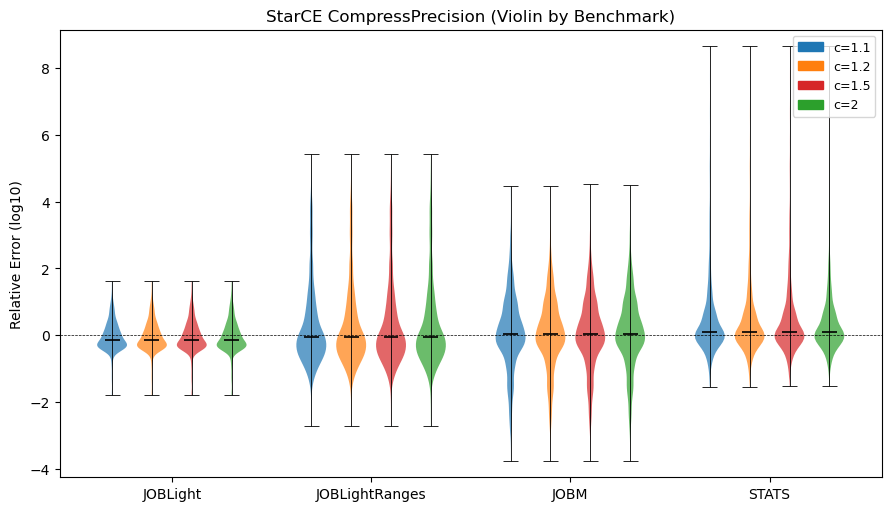

In [11]:
# Violin plot: grouped by benchmark, each group shows all CompressPrecision
precisions_sorted = [float(p) for p in PRECISION_LEVELS]
_palette = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']  # blue,orange,red(1.5),green
precision_colors = {p: _palette[i] for i, p in enumerate(precisions_sorted)}

fig, ax = plt.subplots(layout="constrained", figsize=(max(7, len(all_error_data) * 2.2), 5))
positions, violin_data, violin_colors = [], [], []
benchmark_centers, benchmark_labels = [], []
group_width, group_gap = 0.9, 0.6

for idx, bm in enumerate(sorted(all_error_data.keys()), start=1):
    base_pos = (idx - 1) * (group_width + group_gap) + 1
    offsets = np.linspace(-group_width / 2, group_width / 2, len(precisions_sorted))
    for offset, p in zip(offsets, precisions_sorted):
        if p not in all_error_data.get(bm, {}):
            continue
        pos = base_pos + float(offset)
        log_errs = np.log10(np.maximum(np.array(all_error_data[bm][p]), 1e-10))
        positions.append(pos)
        violin_data.append(log_errs)
        violin_colors.append(precision_colors[p])
    benchmark_centers.append(base_pos)
    benchmark_labels.append(bm)

plot_style.draw_violins(ax, violin_data, positions, violin_colors,
                        widths=group_width / max(len(precisions_sorted), 1))
all_log = np.concatenate(violin_data)
ax.set_ylim(np.min(all_log) - 0.5, np.max(all_log) + 0.5)
ax.set_ylabel("Relative Error (log10)")
ax.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
ax.set_xticks(benchmark_centers)
ax.set_xticklabels(benchmark_labels)
ax.set_title("StarCE CompressPrecision (Violin by Benchmark)")
ax.legend(handles=[mpl.patches.Patch(color=precision_colors[p], label=precision_display(p))
                    for p in precisions_sorted], fontsize=9, loc="best")
f = FIGURE_DIR / "compress_precision_boxplot_benchmarks_grouped.pdf"
plt.savefig(f)
print(f"Saved: {f}")
plt.show()

Saved: /home/user/project/starce-final/StarCE/experiment/checkpoint/figures/compress_precision_boxplot_stats_jobm.pdf


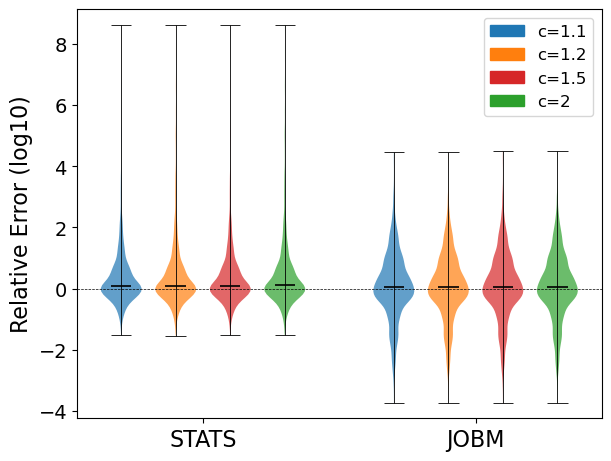

In [12]:
# Modified violin plot: STATS + JOBM only, square, large font
mpl.rcParams.update({'font.size': 14})
selected = ["STATS", "JOBM"]
precisions_sorted = [float(p) for p in PRECISION_LEVELS]
_palette = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']
precision_colors = {p: _palette[i] for i, p in enumerate(precisions_sorted)}

fig, ax = plt.subplots(layout="constrained", figsize=(6, 4.5))
positions, violin_data, violin_colors = [], [], []
benchmark_centers, benchmark_labels = [], []
group_width, group_gap = 0.9, 0.6

for idx, bm in enumerate(selected, start=1):
    if bm not in all_error_data:
        continue
    base_pos = (idx - 1) * (group_width + group_gap) + 1
    offsets = np.linspace(-group_width / 2, group_width / 2, len(precisions_sorted))
    for offset, p in zip(offsets, precisions_sorted):
        if p not in all_error_data[bm]:
            continue
        pos = base_pos + float(offset)
        log_errs = np.log10(np.maximum(np.array(all_error_data[bm][p]), 1e-10))
        positions.append(pos)
        violin_data.append(log_errs)
        violin_colors.append(precision_colors[p])
    benchmark_centers.append(base_pos)
    benchmark_labels.append(bm)

plot_style.draw_violins(ax, violin_data, positions, violin_colors,
                        widths=group_width / max(len(precisions_sorted), 1))
all_log = np.concatenate(violin_data)
ax.set_ylim(np.min(all_log) - 0.5, np.max(all_log) + 0.5)
ax.set_ylabel("Relative Error (log10)", fontsize=16)
ax.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
ax.set_xticks(benchmark_centers)
ax.set_xticklabels(benchmark_labels, fontsize=16)
ax.tick_params(axis='y', labelsize=14)
ax.legend(handles=[mpl.patches.Patch(color=precision_colors[p], label=precision_display(p))
                    for p in precisions_sorted], fontsize=12, loc="best")
f = FIGURE_DIR / "compress_precision_boxplot_stats_jobm.pdf"
plt.savefig(f, bbox_inches='tight')
print(f"Saved: {f}")
plt.show()
mpl.rcParams.update({'font.size': 10})

Saved: /home/user/project/starce-final/StarCE/experiment/checkpoint/figures/compress_precision_stats_size.pdf


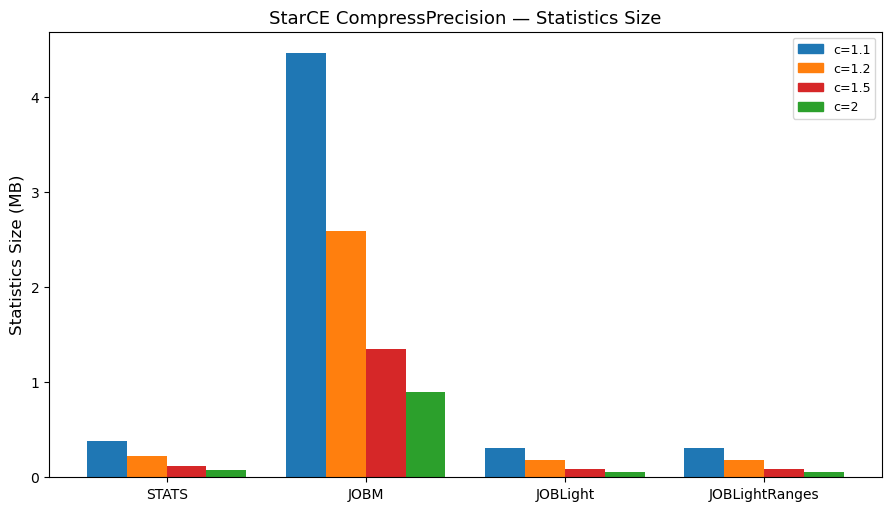

In [13]:
# ============================================================
# Statistics size bar chart
# ============================================================
if df_build is not None:
    precisions_sorted = [float(p) for p in PRECISION_LEVELS]
    _palette = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']
    precision_colors = {p: _palette[i] for i, p in enumerate(precisions_sorted)}

    fig, ax = plt.subplots(layout="constrained", figsize=(max(7, len(BENCHMARKS) * 2.2), 5))

    x = np.arange(len(BENCHMARKS))
    n_prec = len(precisions_sorted)
    width = 0.8 / n_prec

    for i, p in enumerate(precisions_sorted):
        values = []
        for bm in BENCHMARKS:
            mask = (df_build['benchmark'] == bm) & (df_build['compress_precision'] == p)
            row = df_build[mask]
            values.append(row['statistics_size_mb'].values[0] if len(row) > 0 else 0)
        ax.bar(x + i * width, values, width, label=precision_display(p), color=precision_colors[p])

    ax.set_xticks(x + width * (n_prec - 1) / 2)
    ax.set_xticklabels(BENCHMARKS)
    ax.set_ylabel("Statistics Size (MB)", fontsize=12)
    ax.set_title("StarCE CompressPrecision — Statistics Size", fontsize=13)
    ax.legend(handles=[mpl.patches.Patch(color=precision_colors[p], label=precision_display(p))
                        for p in precisions_sorted], fontsize=9)

    f = FIGURE_DIR / "compress_precision_stats_size.pdf"
    plt.savefig(f)
    print(f"Saved: {f}")
    plt.show()
else:
    print("df_build not available, please run the experiment section first or ensure compress_build_results.csv exists")

Saved: /home/user/project/starce-final/StarCE/experiment/checkpoint/figures/compress_precision_stats_size_stats_jobm.pdf


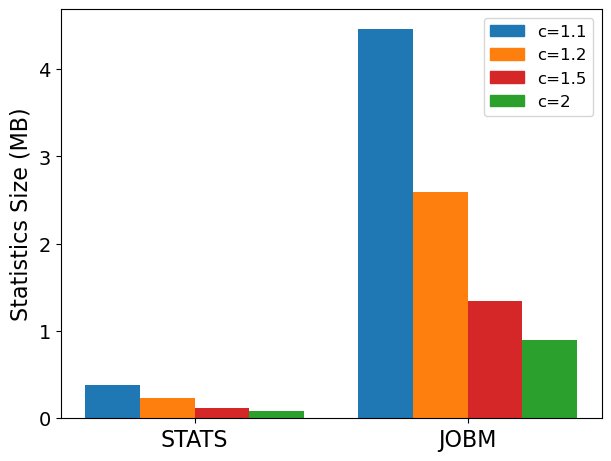

In [14]:
# Statistics size bar chart -- STATS + JOBM only, square
if df_build is not None:
    mpl.rcParams.update({'font.size': 14})
    selected = ["STATS", "JOBM"]
    precisions_sorted = [float(p) for p in PRECISION_LEVELS]
    _palette = ['#1f77b4', '#ff7f0e', '#d62728', '#2ca02c']
    precision_colors = {p: _palette[i] for i, p in enumerate(precisions_sorted)}

    fig, ax = plt.subplots(layout="constrained", figsize=(6, 4.5))

    x = np.arange(len(selected))
    n_prec = len(precisions_sorted)
    width = 0.8 / n_prec

    for i, p in enumerate(precisions_sorted):
        values = []
        for bm in selected:
            mask = (df_build['benchmark'] == bm) & (df_build['compress_precision'] == p)
            row = df_build[mask]
            values.append(row['statistics_size_mb'].values[0] if len(row) > 0 else 0)
        ax.bar(x + i * width, values, width, label=precision_display(p), color=precision_colors[p])

    ax.set_xticks(x + width * (n_prec - 1) / 2)
    ax.set_xticklabels(selected, fontsize=16)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_ylabel("Statistics Size (MB)", fontsize=16)
    ax.legend(handles=[mpl.patches.Patch(color=precision_colors[p], label=precision_display(p))
                        for p in precisions_sorted], fontsize=12)

    f = FIGURE_DIR / "compress_precision_stats_size_stats_jobm.pdf"
    plt.savefig(f, bbox_inches='tight')
    print(f"Saved: {f}")
    plt.show()
    mpl.rcParams.update({'font.size': 10})
else:
    print("df_build not available")